<a href="https://colab.research.google.com/github/cibelerusso/FundamentosemCienciasdeDados/blob/main/Notebooks/Fundamentos_em_Ciencias_de_Dados_Aula_11_KNN_Regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN (K-Nearest Neighbors KNN) para Regressão

## 5500004 Fundamentos em Ciências de Dados

## Profa. Cibele Russo - ICMC USP

Fonte: MOREIRA, João Mendes; CARVALHO, André C. P. L. F. de; HORVÁTH, Tomáš. **A General Introduction to Data Analytics**. 1. ed. Hoboken, NJ: John Wiley & Sons, Inc., 2019.

Notebook criado com apoio de ferramentas da IA generativa: NotebookLM e ChatGPT.

Dados gerados artificialmente pela autora sem uso de IA.




# K-Nearest Neighbors (KNN) para Regressão

Embora o KNN seja frequentemente associado à classificação, ele é igualmente eficaz para prever valores numéricos contínuos (regressão).

Ele mantém sua característica de **aprendizado preguiçoso** (*lazy learning*), o que significa que não constrói um modelo matemático antecipadamente, mas utiliza os dados de treinamento diretamente no momento da predição.

### 1. O Processo de Predição
Diferente da classificação, onde o objetivo é encontrar a classe majoritária, na regressão o KNN busca estimar um valor. O processo segue estes passos:

1.  **Cálculo de Distância:** O algoritmo recebe um novo objeto e calcula a distância (geralmente Euclidiana) entre ele e todos os outros exemplos no conjunto de treinamento.
2.  **Seleção de Vizinhos:** São identificados os **$k$ objetos mais próximos** (vizinhos).
3.  **Cálculo da Média:** O valor previsto para o novo objeto é a **média aritmética** dos valores dos rótulos desses $k$ vizinhos.

### 2. KNN com Média Ponderada
Uma variação comum para melhorar a precisão da regressão é atribuir pesos aos vizinhos. Em vez de uma média simples, pode-se utilizar, por exemplo, uma **média ponderada pelo inverso da distância**.
*   Nesse cenário, vizinhos que estão mecanicamente mais próximos do objeto de teste têm um impacto maior no valor final previsto do que vizinhos mais distantes.

### 3. Considerações Críticas
*   **Escolha de $k$:**
    *   Um $k$ muito **pequeno** torna a predição instável e sensível a ruídos nos dados.
    *   Um $k$ muito **grande** pode incluir vizinhos que são muito diferentes do objeto original, fazendo com que a previsão tenda à média global dos dados e perca a sensibilidade local.
*   **Padronização:** Como o KNN baseia-se inteiramente em medidas de distância, é **obrigatório normalizar os atributos quantitativos**. Sem isso, variáveis com escalas maiores (ex: salário) dominariam o cálculo sobre variáveis com escalas menores (ex: idade), distorcendo a similaridade.
*   **Custo Computacional:** A fase de teste é lenta, pois o algoritmo precisa comparar o novo objeto com todos os exemplos armazenados na memória para cada predição feita.

### 4. Vantagens e Desvantagens
| Vantagens | Desvantagens |
| :--- | :--- |
| Simplicidade e facilidade de implementação. | Custo computacional alto no momento da predição. |
| Naturalmente incremental (novos dados são usados imediatamente). | Sensível a atributos irrelevantes que "sujam" a distância. |
| Eficaz para problemas onde a relação local é forte. | Não fornece um modelo interpretável (apenas a predição). |




## Motivação

Considere uma amostra dos dados de 500 clientes de um banco no arquivo dados_banco.csv. Estão disponíveis as variáveis:

- Cliente: Identificador do cliente.
- Sexo: Feminino (F) ou Masculino (M)
- Idade: Idade do cliente, em anos completos.
- Empresa: Tipo da empresa em que trabalha: Pública, Privada ou Autônomo
- Salário: Salário declarado pelo cliente na abertura da conta, em reais.
- Saldo_cc: Saldo em conta corrente, em reais.
- Saldo_poupança: Saldo em poupança, em reais.
- Saldo_investimento: Saldo em investimentos, em reais.
- Devedor_cartao: Valor em atraso no cartão de crédito, em reais.
- Inadimplente: Se o cliente é considerado inadimplente atualmente (1) ou não (0), de acordo com critérios preestabelecidos.


Imagine que se deseja predizer o salário para clientes a partir de sua idade e do seu saldo em conta corrente.

**Resposta:** `Salario`  
**Preditoras:** `Idade` e `Saldo_cc`  


## 1. Bibliotecas

Vamos carregar as bibliotecas necessárias para manipulação dos dados, visualização e modelagem.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Configurações gerais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42 # fixa a semente para a separação de amostras de treinamento e teste

## 2. Leitura dos dados

Os dados serão lidos diretamente do GitHub.

In [ ]:
url = "https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/amostra_banco.csv"

df = pd.read_csv(url)
df.head()

,Unnamed: 0,Cliente,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente
0,33227,33227,M,38,Privada,6467,993.18,0.00,0.00,2038.32,1
1,64805,64805,M,33,Privada,5764,1167.27,0.00,0.00,4617.05,1
2,39764,39764,F,35,Privada,5417,667.30,0.00,0.00,5726.83,1
3,51271,51271,M,36,Privada,5858,846.53,0.00,0.00,1723.74,1
4,9699,9699,M,32,Privada,5579,768.90,16801.57,8138.71,0.00,0


In [ ]:
len(df)

500

In [ ]:
df[["Salario", "Idade", "Saldo_cc"]].describe()

,Salario,Idade,Saldo_cc
count,500.000000,500.000000,500.000000
mean,5533.932000,31.980000,838.540340
std,433.666199,3.136123,244.251991
min,4459.000000,24.000000,112.050000
25%,5250.000000,30.000000,681.260000
50%,5533.000000,32.000000,834.005000
75%,5779.250000,34.000000,1002.777500
max,8915.000000,53.000000,1838.560000


## 3. Seleção das variáveis

Para este exemplo, vamos utilizar:

- `Salario` como variável resposta;
- `Idade` e `Saldo_cc` como variáveis preditoras.

Também vamos remover observações com valores ausentes nessas três variáveis, caso existam.

In [ ]:
variaveis = ["Salario", "Idade", "Saldo_cc"]

dados = df[variaveis].copy()
dados = dados.dropna()

dados.head()

,Salario,Idade,Saldo_cc
0,6467,38,993.18
1,5764,33,1167.27
2,5417,35,667.30
3,5858,36,846.53
4,5579,32,768.90


In [ ]:
dados.isna().sum()

,0
Salario,0
Idade,0
Saldo_cc,0


## 4. Visualização exploratória

Antes de ajustar o modelo, vamos observar a distribuição da resposta e sua relação com as preditoras.

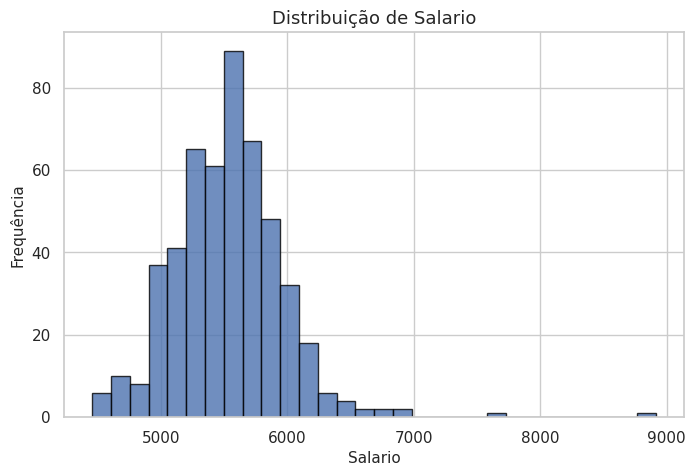

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(dados["Salario"], bins=30, edgecolor="black", alpha=0.8)
ax.set_title("Distribuição de Salario")
ax.set_xlabel("Salario")
ax.set_ylabel("Frequência")
plt.show()

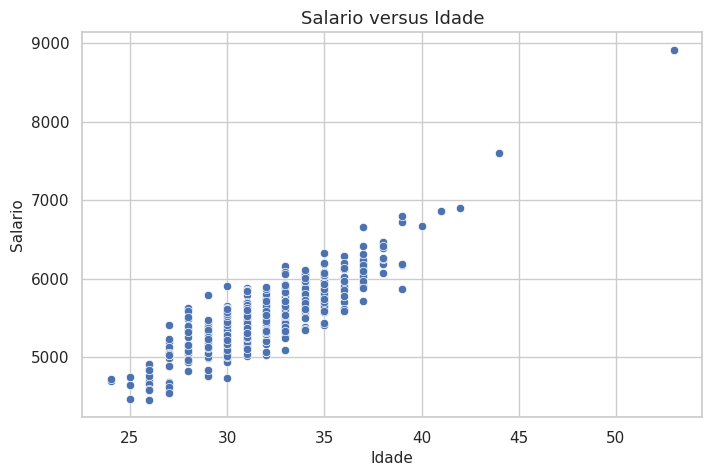

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
sns.scatterplot(data=dados, x="Idade", y="Salario", ax=ax)
ax.set_title("Salario versus Idade")
ax.set_xlabel("Idade")
ax.set_ylabel("Salario")
plt.show()

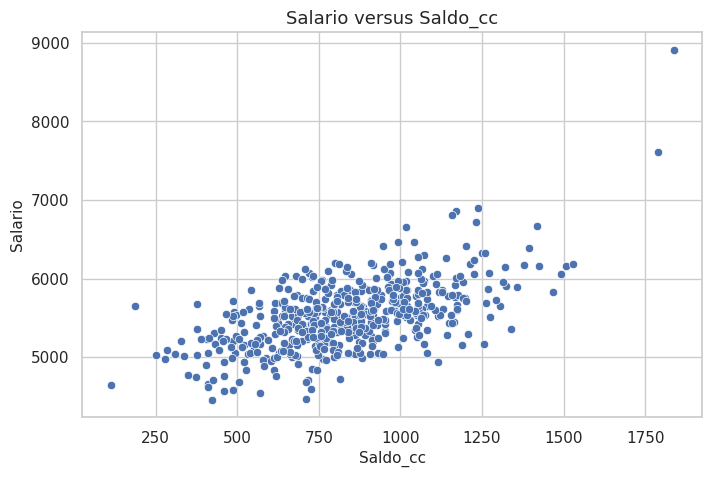

In [ ]:
fig, ax = plt.subplots()
sns.scatterplot(data=dados, x="Saldo_cc", y="Salario", ax=ax)
ax.set_title("Salario versus Saldo_cc")
ax.set_xlabel("Saldo_cc")
ax.set_ylabel("Salario")
plt.show()

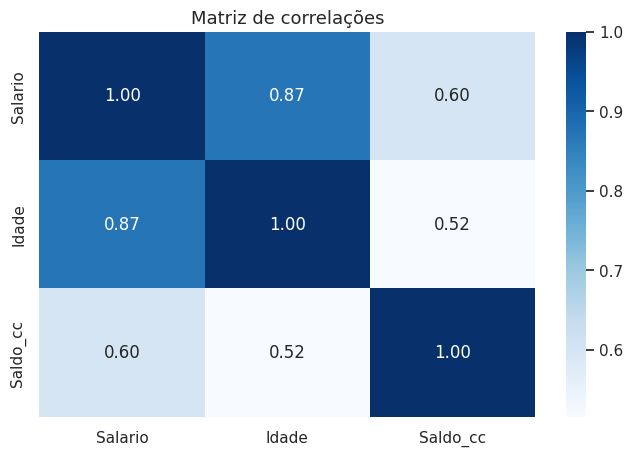

In [ ]:
fig, ax = plt.subplots()
sns.heatmap(dados.corr(numeric_only=True), annot=True, cmap="Blues", fmt=".2f", ax=ax)
ax.set_title("Matriz de correlações")
plt.show()

## 5. Separação dos dados em subconjuntos de treinamento e teste

Vamos separar os dados em uma amostra de treinamento e uma amostra de teste.

Como o KNN depende de distâncias, a padronização das preditoras é importante. Isso será feito dentro de um `Pipeline`, evitando vazamento de informação do conjunto de teste para o treinamento.

In [ ]:
X = dados[["Idade", "Saldo_cc"]]
y = dados["Salario"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Tamanho do treino:", X_train.shape[0])
print("Tamanho do teste:", X_test.shape[0])

Tamanho do treino: 375
Tamanho do teste: 125


## 6. Método KNN para regressão


## Formalização do KNN para regressão

Considere uma amostra com $n$ observações. Para cada observação $i = 1, \ldots, n$, temos duas variáveis preditoras: $X_{1i}$ e $X_{2i}$

e uma variável resposta: $Y_i.$

Assim, cada observação pode ser escrita como $(\mathbf{x}_i, Y_i),$

em que $\mathbf{x}_i = (X_{1i}, X_{2i})$ representa o vetor de preditoras da observação $i$.

Para uma nova observação com preditoras

$\mathbf{x}_0 = (X_{10}, X_{20}),$

queremos prever o valor da resposta $Y_0$.

No método dos $k$ vizinhos mais próximos, calculamos a distância entre $\mathbf{x}_0$ e cada observação da amostra. Usando a distância Euclidiana, temos:

$d(\mathbf{x}_0, \mathbf{x}_i)=\sqrt{(X_{10} - X_{1i})^2 + (X_{20} - X_{2i})^2}.$
Selecionamos então o conjunto $N_k(\mathbf{x}_0)$, formado pelas $k$ observações com menores distâncias em relação a $\mathbf{x}_0$.

Como estamos em um problema de regressão, a predição de $Y_0$ é dada pela média dos valores observados da resposta entre os $k$ vizinhos mais próximos:

$\widehat{Y}_0=\frac{1}{k}\sum_{i \in N_k(\mathbf{x}_0)} Y_i.$

Portanto, o KNN para regressão prevê a resposta de uma nova observação a partir da média das respostas das observações mais próximas no espaço das variáveis preditoras.


No KNN para regressão, a predição para uma nova observação é obtida a partir dos valores da resposta nas observações mais próximas.

Vamos começar com um modelo simples usando `k = 5`.

In [ ]:
modelo_knn_5 = Pipeline(steps=[
    ("padronizacao", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

modelo_knn_5.fit(X_train, y_train)

y_pred_5 = modelo_knn_5.predict(X_test)

In [ ]:
def metricas_regressao(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = root_mean_squared_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)
    return pd.Series({"MAE": mae, "RMSE": rmse, "R2": r2})

metricas_regressao(y_test, y_pred_5)

,0
MAE,179.756800
RMSE,227.458149
R2,0.713849


## 7. Escolha do número de vizinhos

Agora vamos comparar diferentes valores de `k` usando validação cruzada no conjunto de treino.

A métrica utilizada na busca será o RMSE médio de validação cruzada.

In [ ]:
param_grid = {
    "knn__n_neighbors": range(1, 51),
    "knn__weights": ["uniform", "distance"]
}

pipeline = Pipeline(steps=[
    ("padronizacao", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

busca = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=10,
    n_jobs=1
)

busca.fit(X_train, y_train)

print("Melhores parâmetros:", busca.best_params_)
print("Melhor RMSE médio na validação cruzada:", -busca.best_score_)

Melhores parâmetros: {'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Melhor RMSE médio na validação cruzada: 233.04293155577597


In [ ]:
resultados_cv = pd.DataFrame(busca.cv_results_)
resultados_cv["RMSE_medio"] = -resultados_cv["mean_test_score"]
resultados_cv = resultados_cv.sort_values("RMSE_medio")

resultados_cv[["param_knn__n_neighbors", "param_knn__weights", "RMSE_medio", "std_test_score"]].head(10)

,param_knn__n_neighbors,param_knn__weights,RMSE_medio,std_test_score
16,9,uniform,233.042932,96.753043
14,8,uniform,233.687624,94.139108
10,6,uniform,233.915207,89.064293
12,7,uniform,234.896723,94.059090
18,10,uniform,234.968569,96.951484
20,11,uniform,235.093285,95.684990
22,12,uniform,235.528513,96.768529
24,13,uniform,235.743531,97.337474
28,15,uniform,236.088456,98.646106
26,14,uniform,236.273871,98.640855


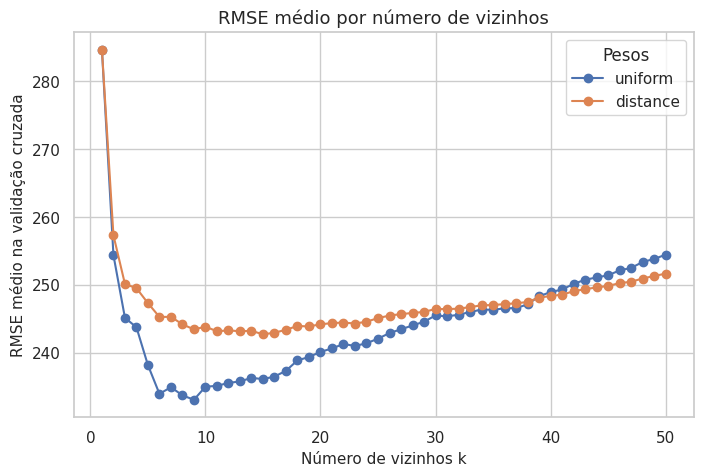

In [ ]:
fig, ax = plt.subplots()

for peso in ["uniform", "distance"]:
    aux = resultados_cv[resultados_cv["param_knn__weights"] == peso].sort_values("param_knn__n_neighbors")
    ax.plot(aux["param_knn__n_neighbors"], aux["RMSE_medio"], marker="o", label=peso)

ax.set_title("RMSE médio por número de vizinhos")
ax.set_xlabel("Número de vizinhos k")
ax.set_ylabel("RMSE médio na validação cruzada")
ax.legend(title="Pesos")
plt.show()

## 8. Avaliação no conjunto de teste

Após escolher os hiperparâmetros usando apenas o conjunto de treino, avaliamos o modelo final no conjunto de teste.

In [ ]:
melhor_modelo = busca.best_estimator_
y_pred = melhor_modelo.predict(X_test)

metricas_teste = metricas_regressao(y_test, y_pred)
metricas_teste

,0
MAE,176.968889
RMSE,225.200676
R2,0.719501


In [ ]:
predicoes = X_test.copy()
predicoes["Salario_real"] = y_test.values
predicoes["Salario_predito"] = y_pred
predicoes["Erro"] = predicoes["Salario_real"] - predicoes["Salario_predito"]

predicoes.head(10)

,Idade,Saldo_cc,Salario_real,Salario_predito,Erro
361,32,787.98,5298,5564.444444,-266.444444
73,37,949.69,6126,6034.888889,91.111111
374,33,878.83,5384,5704.333333,-320.333333
155,26,410.55,4657,4751.444444,-94.444444
104,35,967.51,6185,5808.111111,376.888889
394,35,1018.04,5856,5792.111111,63.888889
377,33,994.72,5547,5759.111111,-212.111111
124,33,1508.37,6158,5847.333333,310.666667
68,27,1080.27,5053,5256.888889,-203.888889
450,28,682.40,5159,5197.666667,-38.666667


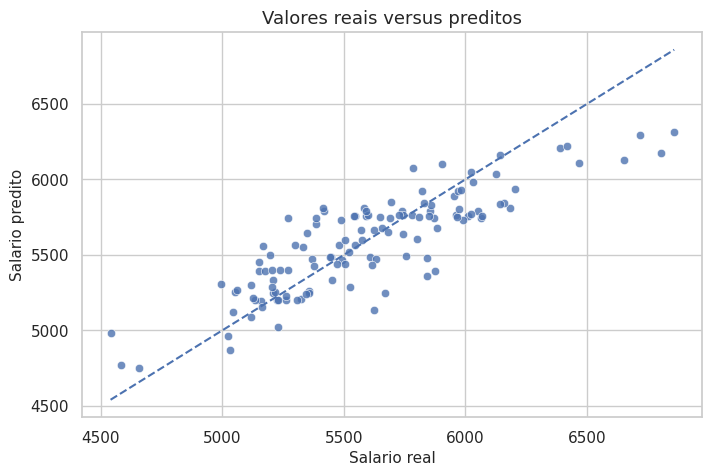

In [ ]:
fig, ax = plt.subplots()
sns.scatterplot(x=y_test, y=y_pred, alpha=0.8, ax=ax)

limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(limites, limites, linestyle="--")

ax.set_title("Valores reais versus preditos")
ax.set_xlabel("Salario real")
ax.set_ylabel("Salario predito")
plt.show()

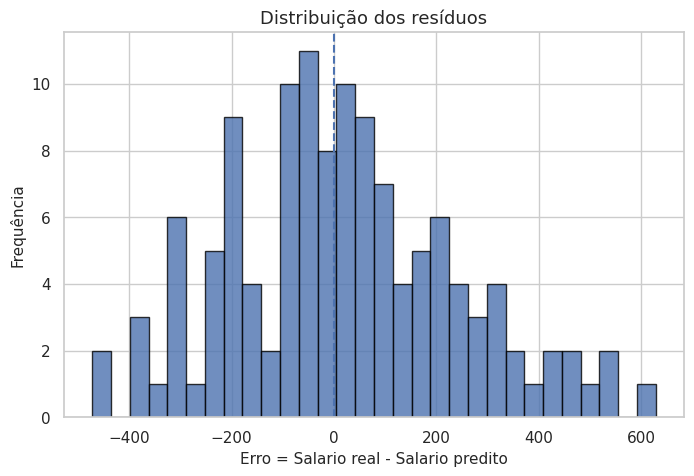

In [ ]:
fig, ax = plt.subplots()
ax.hist(predicoes["Erro"], bins=30, edgecolor="black", alpha=0.8)
ax.axvline(0, linestyle="--")
ax.set_title("Distribuição dos resíduos")
ax.set_xlabel("Erro = Salario real - Salario predito")
ax.set_ylabel("Frequência")
plt.show()

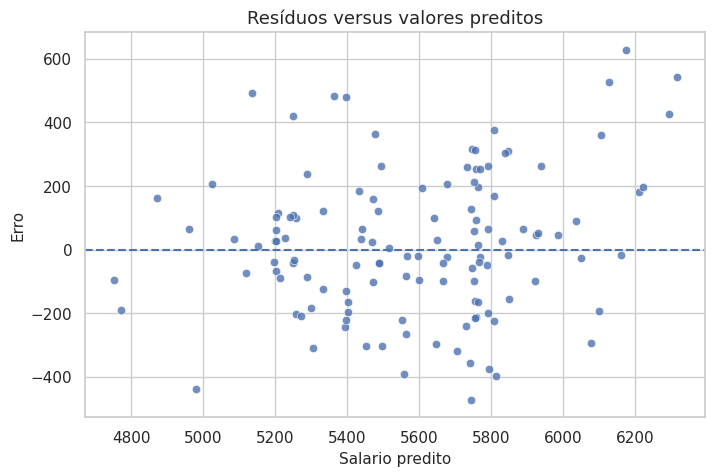

In [ ]:
fig, ax = plt.subplots()
sns.scatterplot(data=predicoes, x="Salario_predito", y="Erro", alpha=0.8, ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title("Resíduos versus valores preditos")
ax.set_xlabel("Salario predito")
ax.set_ylabel("Erro")
plt.show()

## 9. Visualização da superfície de predição

Como usamos apenas duas preditoras, podemos visualizar a superfície estimada pelo KNN no plano formado por `Idade` e `Saldo_cc`.

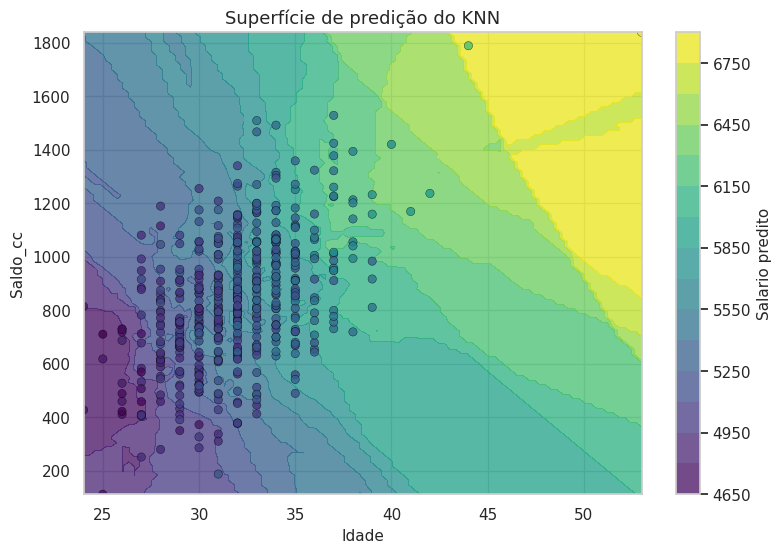

In [ ]:
idade_grid = np.linspace(X["Idade"].min(), X["Idade"].max(), 100)
saldo_grid = np.linspace(X["Saldo_cc"].min(), X["Saldo_cc"].max(), 100)
idade_mesh, saldo_mesh = np.meshgrid(idade_grid, saldo_grid)

grade = pd.DataFrame({
    "Idade": idade_mesh.ravel(),
    "Saldo_cc": saldo_mesh.ravel()
})

salario_pred_grid = melhor_modelo.predict(grade).reshape(idade_mesh.shape)

fig, ax = plt.subplots(figsize=(9, 6))
contorno = ax.contourf(idade_mesh, saldo_mesh, salario_pred_grid, levels=20, cmap="viridis", alpha=0.75)
plt.colorbar(contorno, ax=ax, label="Salario predito")

sns.scatterplot(
    data=dados,
    x="Idade",
    y="Saldo_cc",
    hue="Salario",
    palette="viridis",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.8,
    ax=ax,
    legend=False
)

ax.set_title("Superfície de predição do KNN")
ax.set_xlabel("Idade")
ax.set_ylabel("Saldo_cc")
plt.show()

## 10. Predição para novos clientes

Podemos usar o modelo ajustado para prever o salário de novos clientes a partir de `Idade` e `Saldo_cc`.

In [ ]:
novos_clientes = pd.DataFrame({
    "Idade": [25, 40, 60],
    "Saldo_cc": [500, 3000, 10000]
})

novos_clientes["Salario_predito"] = melhor_modelo.predict(novos_clientes)
novos_clientes

,Idade,Saldo_cc,Salario_predito
0,25,500,4697.777778
1,40,3000,6663.333333
2,60,10000,6728.222222


## 11. Comentários finais

Neste notebook, ajustamos um modelo KNN para regressão com duas preditoras.

Pontos importantes:

- o KNN é sensível à escala das variáveis, por isso usamos padronização;
- o valor de `k` controla o grau de suavização das predições;
- valores pequenos de `k` podem gerar modelos mais variáveis;
- valores grandes de `k` podem gerar modelos excessivamente suavizados;
- a escolha de `k` foi feita por validação cruzada no conjunto de treino.
